# Simple Pair Backtest

A minimal notebook to backtest any two-ETF pair with periodic rebalancing.

## What this does
- Supports long/short direction per leg
- Rebalances both legs once per chosen period
- Sizes notionals to hit a target net beta exposure (default: beta-neutral)
- Tracks equity curve, drawdown, and simple performance stats

## Starter pair
- Leg A: `APLX` (short)
- Leg B: `APLZ` (short)
- Target: net beta exposure = 0


In [23]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

In [38]:
# --- Parameters ---
LEG_A_TICKER = "APLZ"
LEG_B_TICKER = "APLX"
START = "2024-01-01"
END = None

# Direction: +1 = long, -1 = short
LEG_A_SIDE = -1
LEG_B_SIDE = -1

# Beta to underlying (or benchmark beta exposure) for each leg
# Used as manual fallback if auto lookup does not find a value.
LEG_A_BETA = 2.0
LEG_B_BETA = -2.0
USE_BETA_FROM_SCREENED = True
BETA_SOURCE_CSV = "../data/etf_screened_today.csv"

INITIAL_CAPITAL = 100_000
TARGET_GROSS_MULTIPLIER = 1.0   # gross notional as multiple of equity
TARGET_NET_BETA_NOTIONAL = 0.0  # 0 = beta-neutral

# Borrow settings (applies daily carry on short legs)
USE_BORROW_FROM_SCREENED = True
BORROW_SOURCE_CSV = "../data/etf_screened_today.csv"
BORROW_FALLBACK_ANNUAL = 0.1
MANUAL_BORROW_OVERRIDE = {
    # "APLX": 0.35,
    # "APLZ": 0.12,
}

# Pandas offset alias examples: "W-FRI", "W", "M", "Q"
REBALANCE_FREQ = "W-FRI"

# Per-trade cost in bps applied to gross notional traded
FEE_BPS = 0.0

In [39]:
def load_prices(leg_a_ticker: str, leg_b_ticker: str, start: str, end: str | None = None) -> pd.DataFrame:
    data = yf.download(
        [leg_a_ticker, leg_b_ticker],
        start=start,
        end=end,
        auto_adjust=True,
        progress=False,
    )

    if isinstance(data.columns, pd.MultiIndex):
        px = data["Close"].copy()
    else:
        px = data[["Close"]].rename(columns={"Close": leg_a_ticker})

    px = px.rename(columns={leg_a_ticker: "a_px", leg_b_ticker: "b_px"}).dropna()
    if px.empty:
        raise RuntimeError("No overlapping price data for selected pair.")
    return px


def load_borrow_rates(
    ticker_a: str,
    ticker_b: str,
    screened_csv: str,
    use_screened: bool,
    fallback_annual: float,
    manual_override: dict[str, float] | None = None,
) -> tuple[float, float]:
    rates = {ticker_a.upper(): float(fallback_annual), ticker_b.upper(): float(fallback_annual)}

    if use_screened:
        try:
            df = pd.read_csv(screened_csv)
            if "ETF" in df.columns and "borrow_current" in df.columns:
                df["ETF"] = df["ETF"].astype(str).str.upper().str.strip()
                tmp = df[["ETF", "borrow_current"]].dropna()
                for _, r in tmp.iterrows():
                    etf = str(r["ETF"])
                    if etf in rates:
                        rates[etf] = float(r["borrow_current"])
        except Exception as e:
            print(f"[WARN] Could not load borrow rates from {screened_csv}: {e}")

    if manual_override:
        for k, v in manual_override.items():
            rates[str(k).upper()] = float(v)

    return rates[ticker_a.upper()], rates[ticker_b.upper()]


def load_beta_values(
    ticker_a: str,
    ticker_b: str,
    screened_csv: str,
    use_screened: bool,
    fallback_a: float,
    fallback_b: float,
) -> tuple[float, float]:
    beta_map = {ticker_a.upper(): float(fallback_a), ticker_b.upper(): float(fallback_b)}

    if use_screened:
        try:
            df = pd.read_csv(screened_csv)
            cols_lower = {c.lower(): c for c in df.columns}
            etf_col = cols_lower.get("etf")
            beta_col = cols_lower.get("beta")
            if etf_col and beta_col:
                df[etf_col] = df[etf_col].astype(str).str.upper().str.strip()
                tmp = df[[etf_col, beta_col]].dropna()
                for _, r in tmp.iterrows():
                    etf = str(r[etf_col])
                    if etf in beta_map:
                        beta_map[etf] = float(r[beta_col])
        except Exception as e:
            print(f"[WARN] Could not load betas from {screened_csv}: {e}")

    return beta_map[ticker_a.upper()], beta_map[ticker_b.upper()]


def solve_beta_hedged_notionals(
    gross_notional: float,
    side_a: float,
    side_b: float,
    beta_a: float,
    beta_b: float,
    target_net_beta_notional: float = 0.0,
) -> tuple[float, float]:
    """
    Solve for non-negative gross notionals (n_a, n_b) such that:
      n_a + n_b = gross_notional
      side_a*beta_a*n_a + side_b*beta_b*n_b = target_net_beta_notional
    """
    a = float(side_a) * float(beta_a)
    b = float(side_b) * float(beta_b)
    g = float(gross_notional)
    t = float(target_net_beta_notional)

    denom = a - b
    if abs(denom) < 1e-12:
        n_a = 0.5 * g
        n_b = 0.5 * g
    else:
        n_a = (t - b * g) / denom
        n_b = g - n_a

    # Keep it robust in edge cases.
    n_a = max(0.0, n_a)
    n_b = max(0.0, n_b)
    s = n_a + n_b
    if s <= 0:
        return 0.5 * g, 0.5 * g
    return g * n_a / s, g * n_b / s


def run_pair_backtest(
    prices: pd.DataFrame,
    rebal_freq: str = "W-FRI",
    initial_capital: float = 100_000,
    gross_multiplier: float = 1.0,
    side_a: float = -1.0,
    side_b: float = -1.0,
    beta_a: float = 2.0,
    beta_b: float = -2.0,
    target_net_beta_notional: float = 0.0,
    borrow_a_annual: float = 0.0,
    borrow_b_annual: float = 0.0,
    fee_bps: float = 0.0,
) -> pd.DataFrame:
    bt = prices.copy()
    bt["rebalance"] = False

    rebalance_dates = bt.resample(rebal_freq).last().index
    bt.loc[bt.index.isin(rebalance_dates), "rebalance"] = True
    bt.iloc[0, bt.columns.get_loc("rebalance")] = True

    a_sh = 0.0
    b_sh = 0.0
    cash = float(initial_capital)

    rows = []
    fee_rate = fee_bps / 10_000.0
    borrow_a_daily = float(borrow_a_annual) / 252.0
    borrow_b_daily = float(borrow_b_annual) / 252.0

    for dt, row in bt.iterrows():
        ap = float(row["a_px"])
        bp = float(row["b_px"])

        a_pos_notional = a_sh * ap  # signed (+ long / - short)
        b_pos_notional = b_sh * bp

        # Daily borrow carry on short legs only.
        borrow_cost = 0.0
        if a_pos_notional < 0:
            borrow_cost += abs(a_pos_notional) * borrow_a_daily
        if b_pos_notional < 0:
            borrow_cost += abs(b_pos_notional) * borrow_b_daily
        cash -= borrow_cost

        equity = cash + a_pos_notional + b_pos_notional

        if bool(row["rebalance"]):
            target_gross = max(0.0, float(gross_multiplier) * equity)
            n_a, n_b = solve_beta_hedged_notionals(
                gross_notional=target_gross,
                side_a=side_a,
                side_b=side_b,
                beta_a=beta_a,
                beta_b=beta_b,
                target_net_beta_notional=target_net_beta_notional,
            )

            target_a_pos = float(side_a) * n_a
            target_b_pos = float(side_b) * n_b

            delta_a = target_a_pos - a_pos_notional
            delta_b = target_b_pos - b_pos_notional

            traded_gross = abs(delta_a) + abs(delta_b)
            fee = traded_gross * fee_rate

            cash -= delta_a
            cash -= delta_b
            cash -= fee

            a_sh = target_a_pos / ap if ap > 0 else 0.0
            b_sh = target_b_pos / bp if bp > 0 else 0.0

            a_pos_notional = a_sh * ap
            b_pos_notional = b_sh * bp
            equity = cash + a_pos_notional + b_pos_notional

        beta_notional = side_a * beta_a * abs(a_pos_notional) + side_b * beta_b * abs(b_pos_notional)

        rows.append(
            {
                "date": dt,
                "a_px": ap,
                "b_px": bp,
                "cash": cash,
                "a_shares": a_sh,
                "b_shares": b_sh,
                "a_pos_notional": a_pos_notional,
                "b_pos_notional": b_pos_notional,
                "gross_notional": abs(a_pos_notional) + abs(b_pos_notional),
                "beta_notional": beta_notional,
                "borrow_cost": borrow_cost,
                "equity": equity,
                "rebalance": bool(row["rebalance"]),
            }
        )

    out = pd.DataFrame(rows).set_index("date")
    out["ret"] = out["equity"].pct_change().fillna(0.0)
    out["cum_return"] = out["equity"] / out["equity"].iloc[0] - 1.0
    out["drawdown"] = out["equity"] / out["equity"].cummax() - 1.0
    out["cum_borrow_cost"] = out["borrow_cost"].cumsum()
    return out


def perf_stats(bt: pd.DataFrame) -> pd.Series:
    n = len(bt)
    if n < 2:
        return pd.Series(dtype=float)

    total_return = bt["equity"].iloc[-1] / bt["equity"].iloc[0] - 1.0
    ann_factor = 252 / max(1, n - 1)
    cagr = (1 + total_return) ** ann_factor - 1 if total_return > -1 else np.nan

    vol = bt["ret"].std() * np.sqrt(252)
    sharpe = (bt["ret"].mean() * 252 / vol) if vol > 0 else np.nan
    max_dd = bt["drawdown"].min()

    return pd.Series(
        {
            "Total Return": total_return,
            "CAGR": cagr,
            "Annual Vol": vol,
            "Sharpe": sharpe,
            "Max Drawdown": max_dd,
            "Avg |Beta Notional|": bt["beta_notional"].abs().mean(),
            "Total Borrow Cost": bt["borrow_cost"].sum(),
            "Rebalance Count": int(bt["rebalance"].sum()),
        }
    )

In [40]:
prices = load_prices(LEG_A_TICKER, LEG_B_TICKER, START, END)

beta_a, beta_b = load_beta_values(
    LEG_A_TICKER,
    LEG_B_TICKER,
    BETA_SOURCE_CSV,
    USE_BETA_FROM_SCREENED,
    LEG_A_BETA,
    LEG_B_BETA,
)

borrow_a, borrow_b = load_borrow_rates(
    LEG_A_TICKER,
    LEG_B_TICKER,
    BORROW_SOURCE_CSV,
    USE_BORROW_FROM_SCREENED,
    BORROW_FALLBACK_ANNUAL,
    MANUAL_BORROW_OVERRIDE,
)

bt = run_pair_backtest(
    prices,
    rebal_freq=REBALANCE_FREQ,
    initial_capital=INITIAL_CAPITAL,
    gross_multiplier=TARGET_GROSS_MULTIPLIER,
    side_a=LEG_A_SIDE,
    side_b=LEG_B_SIDE,
    beta_a=beta_a,
    beta_b=beta_b,
    target_net_beta_notional=TARGET_NET_BETA_NOTIONAL,
    borrow_a_annual=borrow_a,
    borrow_b_annual=borrow_b,
    fee_bps=FEE_BPS,
)

stats = perf_stats(bt)
side_map = {1: "LONG", -1: "SHORT"}
print(
    f"Pair: {side_map.get(LEG_A_SIDE, LEG_A_SIDE)} {LEG_A_TICKER} / "
    f"{side_map.get(LEG_B_SIDE, LEG_B_SIDE)} {LEG_B_TICKER}"
)
print(f"Window: {bt.index.min().date()} -> {bt.index.max().date()} | rows={len(bt)}")
print(
    f"Target beta-notional: {TARGET_NET_BETA_NOTIONAL:.2f} | "
    f"Gross multiple: {TARGET_GROSS_MULTIPLIER:.2f}x"
)
print(f"Betas used: {LEG_A_TICKER}={beta_a:.4f}, {LEG_B_TICKER}={beta_b:.4f}")
print(f"Borrow rates used: {LEG_A_TICKER}={borrow_a:.2%}, {LEG_B_TICKER}={borrow_b:.2%}")
display(stats.to_frame("value"))

Pair: SHORT APLZ / SHORT APLX
Window: 2026-01-22 -> 2026-03-31 | rows=48
Target beta-notional: 0.00 | Gross multiple: 1.00x
Betas used: APLZ=-1.9837, APLX=1.9930
Borrow rates used: APLZ=49.30%, APLX=10.00%


,value
Total Return,0.430731
CAGR,5.824254
Annual Vol,0.488394
Sharpe,4.085598
Max Drawdown,-0.054236
Avg |Beta Notional|,21507.871538
Total Borrow Cost,6511.571751
Rebalance Count,11.000000


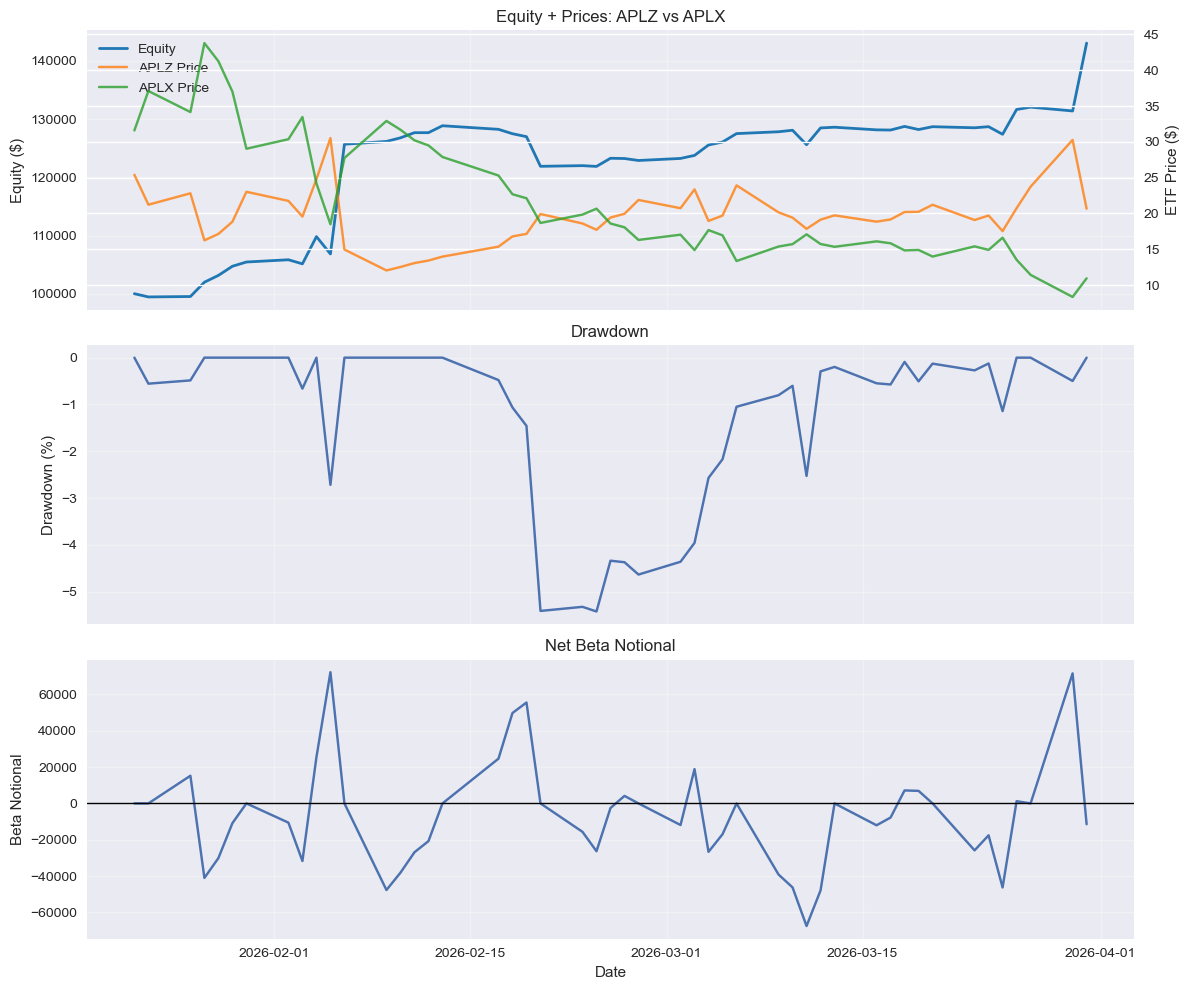

,a_pos_notional,b_pos_notional,beta_notional,equity
date,,,,
2026-01-22,-50117.105736,-49882.894264,1.455192e-11,100000.000000
2026-01-23,-49838.476288,-49605.566931,4.365575e-11,99444.043219
2026-01-30,-52846.693930,-52599.726318,1.455192e-11,105446.420249
2026-02-06,-62991.760222,-62697.381833,1.455192e-11,125689.142055
2026-02-13,-64585.531847,-64283.705310,0.000000e+00,128869.237157
2026-02-20,-61090.330144,-60804.837678,2.910383e-11,121895.167821
2026-02-27,-61592.316558,-61304.478166,1.455192e-11,122896.794724
2026-03-06,-63908.066076,-63609.405529,0.000000e+00,127517.471605
2026-03-13,-64457.496541,-64156.268350,-1.455192e-11,128613.764891


In [41]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Equity + both ETF prices (secondary axis)
ax_eq = axes[0]
ax_px = ax_eq.twinx()

line_eq = ax_eq.plot(bt.index, bt["equity"], label="Equity", color="tab:blue", linewidth=2)
line_a = ax_px.plot(prices.index, prices["a_px"], label=f"{LEG_A_TICKER} Price", color="tab:orange", alpha=0.8)
line_b = ax_px.plot(prices.index, prices["b_px"], label=f"{LEG_B_TICKER} Price", color="tab:green", alpha=0.8)

ax_eq.set_title(f"Equity + Prices: {LEG_A_TICKER} vs {LEG_B_TICKER}")
ax_eq.set_ylabel("Equity ($)")
ax_px.set_ylabel("ETF Price ($)")
ax_eq.grid(True, alpha=0.3)

lines = line_eq + line_a + line_b
labels = [l.get_label() for l in lines]
ax_eq.legend(lines, labels, loc="upper left")

axes[1].plot(bt.index, bt["drawdown"] * 100)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown (%)")
axes[1].grid(True, alpha=0.3)

axes[2].plot(bt.index, bt["beta_notional"], label="Net Beta Notional")
axes[2].axhline(0.0, color="black", linewidth=1)
axes[2].set_title("Net Beta Notional")
axes[2].set_ylabel("Beta Notional")
axes[2].set_xlabel("Date")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Optional quick look at first rebalances
bt.loc[bt["rebalance"], ["a_pos_notional", "b_pos_notional", "beta_notional", "equity"]].head(10)